In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [5]:
train_df.shape

(60000, 785)

In [6]:
test_df.shape

(10000, 785)

In [7]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [9]:
train_df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [10]:
test_df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [11]:
train_df['label'].unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

In [12]:
train_df['label'].value_counts()

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64

In [13]:
x_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

In [14]:
x_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

In [15]:
# Normalize + reshape (28x28 images)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

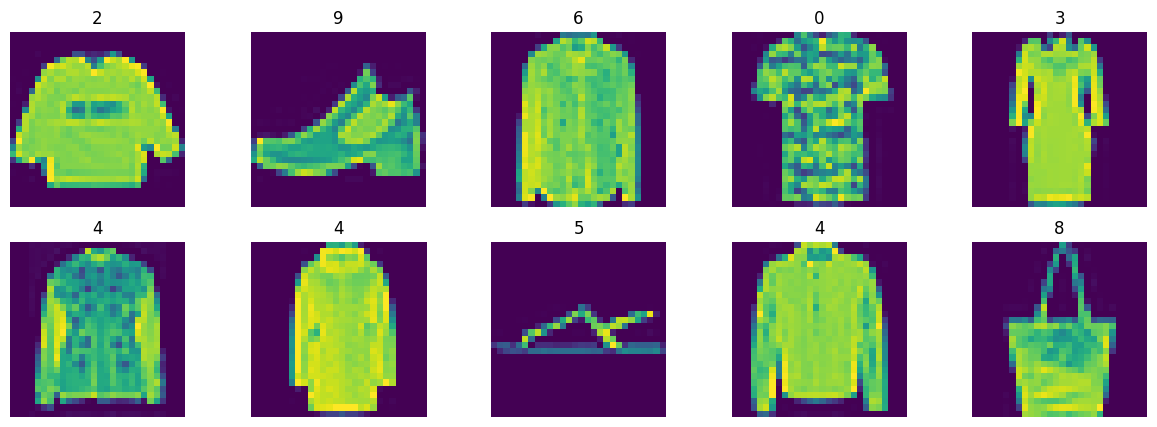

In [19]:
plt.figure(figsize=(15,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28))
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [20]:
model = Sequential([
    # Convolution Layer 1
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),
    MaxPooling2D((2,2)),
    # Flatten Layer
    Flatten(),
    # Dense Layers
    Dense(128, activation='relu'),
    # Output Layer
    Dense(10, activation='softmax')
])

C:\Users\riyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8393 - loss: 0.4554 - val_accuracy: 0.8716 - val_loss: 0.3616
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8917 - loss: 0.3037 - val_accuracy: 0.8917 - val_loss: 0.3060
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9071 - loss: 0.2585 - val_accuracy: 0.9016 - val_loss: 0.2819
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9183 - loss: 0.2252 - val_accuracy: 0.9054 - val_loss: 0.2660
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9256 - loss: 0.2025 - val_accuracy: 0.9033 - val_loss: 0.2751
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9351 - loss: 0.1783 - val_accuracy: 0.9128 - val_loss: 0.2497
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9414 - loss: 0.1600 - val_accuracy: 0.9103 - val_loss: 0.2555
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9505 - loss: 0.1380 - 

In [26]:
metrics = model.evaluate(x_test, y_test)
metrics

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9137 - loss: 0.2683


[0.2683345079421997, 0.9136999845504761]

In [39]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1000
           1       0.98      0.99      0.99      1000
           2       0.92      0.82      0.86      1000
           3       0.93      0.93      0.93      1000
           4       0.78      0.95      0.86      1000
           5       1.00      0.95      0.97      1000
           6       0.82      0.71      0.76      1000
           7       0.94      0.98      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.96      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



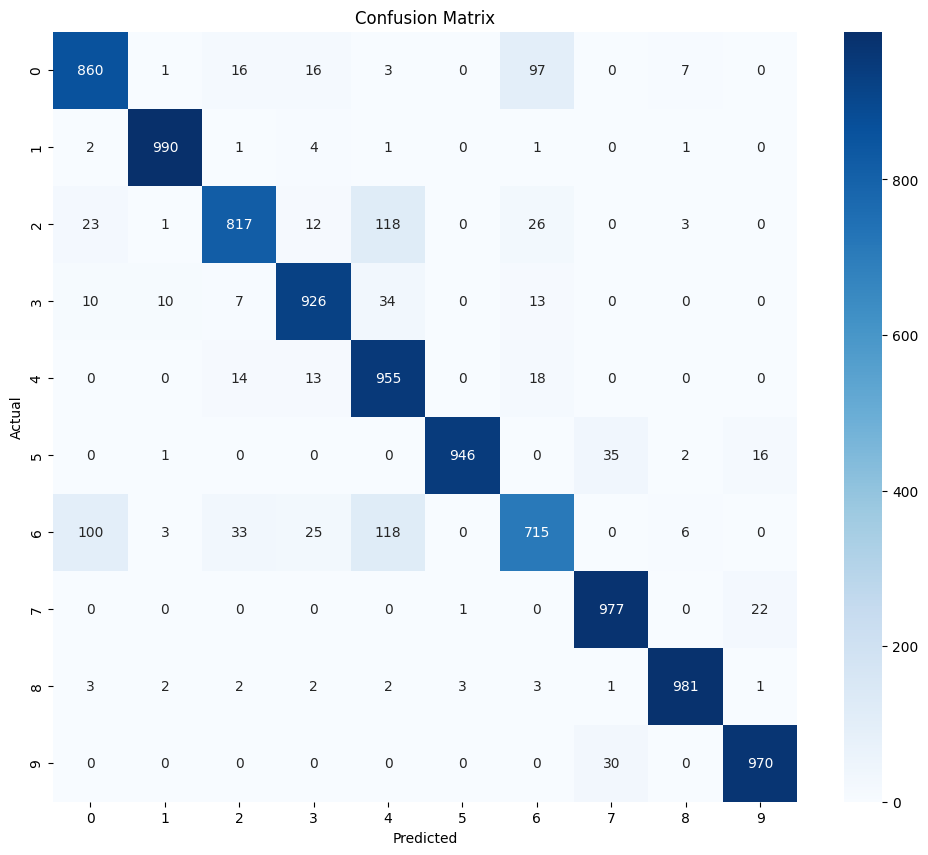

In [41]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Label : 9
Actual Label    : 9
Correct Label Predicted


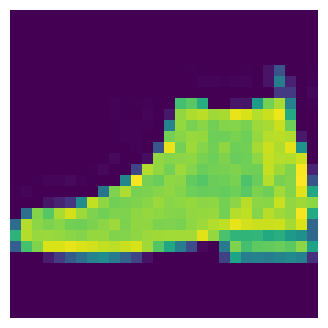

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Label : 3
Actual Label    : 3
Correct Label Predicted


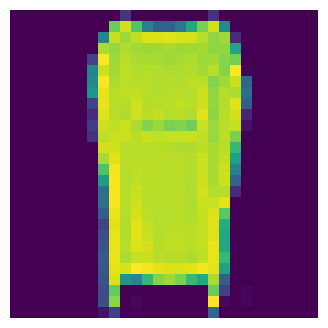

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted Label : 9
Actual Label    : 9
Correct Label Predicted


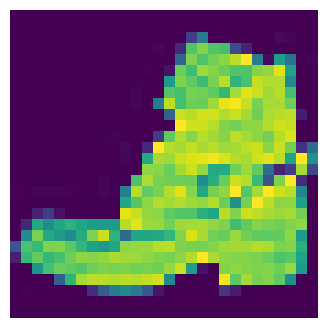

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted Label : 4
Actual Label    : 0
Incorrect Label Predicted


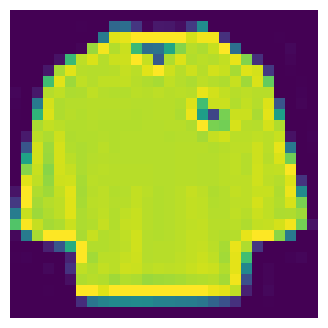

In [43]:
for i in range (100,104):
    image_index = i
    prediction = model.predict(x_test[image_index:image_index+1])
    predicted_label = np.argmax(prediction)
    true_label = y_test[image_index]
    # Print numeric labels
    print("Predicted Label :", predicted_label)
    print("Actual Label    :", true_label)
    # Check prediction
    if predicted_label == true_label:
        print("Correct Label Predicted")
    else:
        print("Incorrect Label Predicted")
    # Display image
    plt.figure(figsize=(4,4))
    plt.imshow(
        x_test[image_index].reshape(28,28))
    plt.axis('off')
    plt.show()